✅ 2D Asset kaydedildi: ../../../assets/52_clt_2d.png


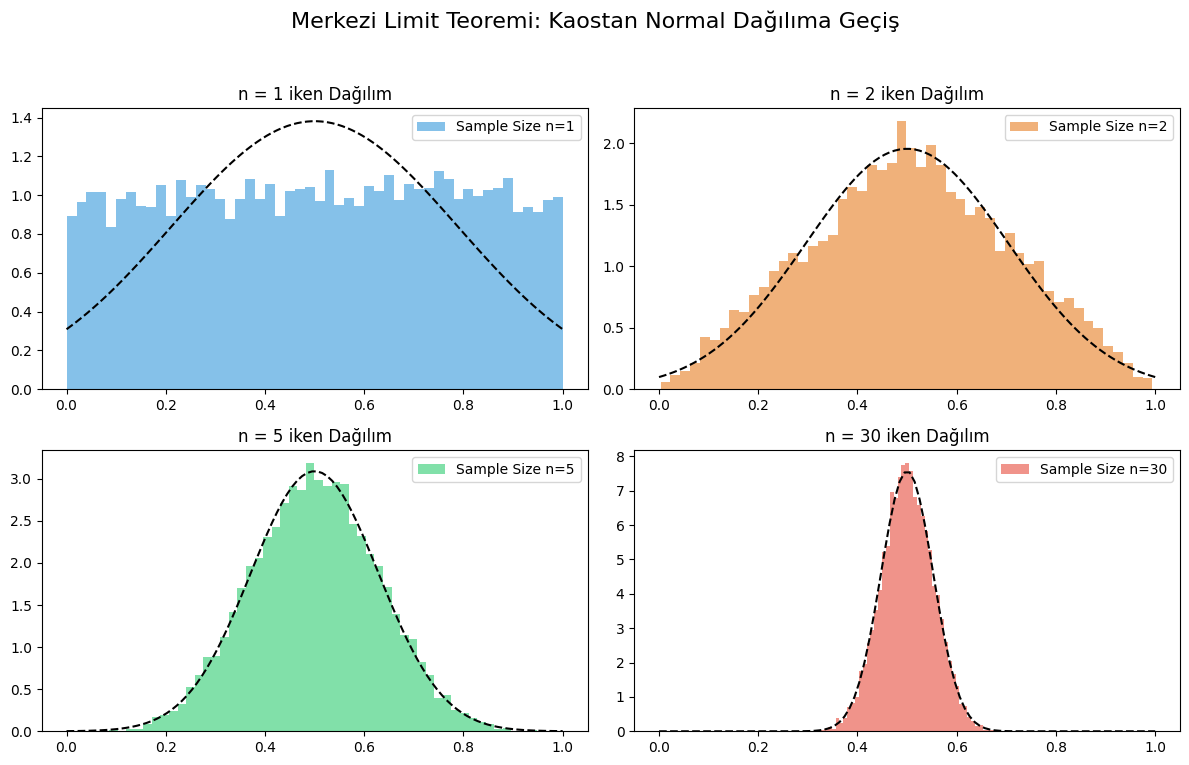

✅ 3D Asset kaydedildi: ../../../assets/52_clt_3d.png


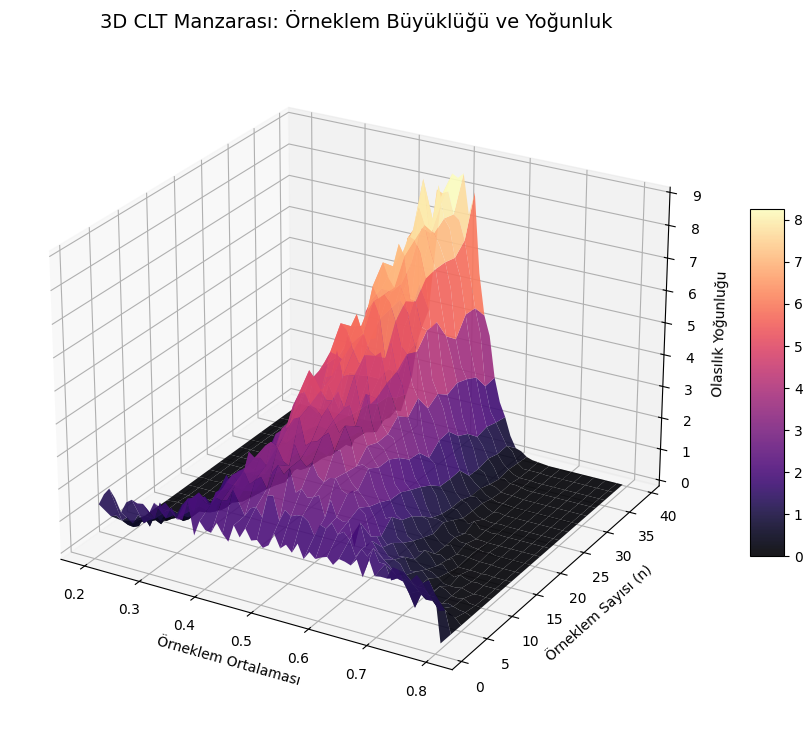

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import os

def run_clt_master():
    # --- PROFESYONEL YOL AYARI (Relative Path) ---
    asset_path = r'../../../assets'
    if not os.path.exists(asset_path):
        os.makedirs(asset_path)

    # 1. Simülasyon Parametreleri
    n_samples_list = [1, 2, 5, 30] # Farklı örneklem büyüklükleri
    n_simulations = 10000          # Kaç kez örneklem alacağız?
    
    # Başlangıç: Uniform (Düz) Dağılım [0, 1] -> Mu=0.5, Var=1/12
    data_source = np.random.uniform(0, 1, (n_simulations, max(n_samples_list)))

    # --- 📸 ASSET 1: 2D EVOLUTION (52_clt_2d.png) ---
    fig1 = plt.figure(figsize=(12, 8))
    colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c']
    
    for i, n in enumerate(n_samples_list):
        # Her simülasyon için n tanesinin ortalamasını al
        means = np.mean(data_source[:, :n], axis=1)
        
        plt.subplot(2, 2, i+1)
        plt.hist(means, bins=50, density=True, color=colors[i], alpha=0.6, 
                 label=f'Sample Size n={n}')
        
        # Teorik Normal Dağılım Eğrisi (Fit)
        mu_mean = 0.5
        sigma_mean = np.sqrt((1/12) / n)
        x_axis = np.linspace(0, 1, 100)
        plt.plot(x_axis, norm.pdf(x_axis, mu_mean, sigma_mean), 'k--', lw=1.5)
        
        plt.title(f"n = {n} iken Dağılım")
        plt.legend()

    plt.suptitle("Merkezi Limit Teoremi: Kaostan Normal Dağılıma Geçiş", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(os.path.join(asset_path, '52_clt_2d.png'), dpi=300)
    print(f"✅ 2D Asset kaydedildi: {asset_path}/52_clt_2d.png")
    plt.show()

    # --- 📸 ASSET 2: 3D PROBABILITY SURFACE (52_clt_3d.png) ---
    fig2 = plt.figure(figsize=(12, 9))
    ax3d = fig2.add_subplot(111, projection='3d')
    
    # 3D için n değerlerini daha sık seçelim
    n_range = np.arange(1, 41, 2)
    x_bins = np.linspace(0.2, 0.8, 60)
    X_grid, N_grid = np.meshgrid(x_bins, n_range)
    Z_density = np.zeros_like(X_grid)

    for i, n in enumerate(n_range):
        means = np.mean(np.random.uniform(0, 1, (5000, n)), axis=1)
        hist, _ = np.histogram(means, bins=x_bins, density=True)
        Z_density[i, :-1] = hist

    surf = ax3d.plot_surface(X_mesh := X_grid, Y_mesh := N_grid, Z_density, 
                             cmap='magma', alpha=0.9, edgecolor='none')
    
    ax3d.set_title("3D CLT Manzarası: Örneklem Büyüklüğü ve Yoğunluk", fontsize=14)
    ax3d.set_xlabel('Örneklem Ortalaması'); ax3d.set_ylabel('Örneklem Sayısı (n)'); ax3d.set_zlabel('Olasılık Yoğunluğu')
    fig2.colorbar(surf, ax=ax3d, shrink=0.5, aspect=10)
    
    # Açıyı çan eğrilerinin yükselişini görecek şekilde ayarla
    ax3d.view_init(elev=25, azim=-60)

    plt.savefig(os.path.join(asset_path, '52_clt_3d.png'), dpi=300)
    print(f"✅ 3D Asset kaydedildi: {asset_path}/52_clt_3d.png")
    plt.show()

if __name__ == "__main__":
    run_clt_master()